### 1. Introduction

The main purpose of this project is building kNN model from scratch and apply to sample dataset for evaluation. Initially, I built a kNN model for a small dataset and defined the evaluation metrics. Next, I applied a larger dataset to compare the performance of the model across different sizes of data.

### 2. Car Evaluation Dataset

#### 2.1. Data pre-peprocessing

Target of the multi-class classification problem is to classify the given car dataset into 2 classes: Unacceptable (0) and Acceptable (1)

Independant Variables:

- buying: buying price
- maint: maintenance price
- doors: numbers of doors
- persons: capacity in terms of persons to carry
- lug_boot: the size of luggage boot
- safety: estimated safety of the car
- Target variable: Class

In [24]:
# load packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
# load data
df = pd.read_csv("car_evaluation.csv", header = None)

In [26]:
df.sample()

,0,1,2,3,4,5,6
665,high,med,2,4,big,high,acc


In [27]:
df.describe(include='all')

,0,1,2,3,4,5,6
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [28]:
df.dtypes

0    object
1    object
2    object
3    object
4    object
5    object
6    object
dtype: object

In [29]:
# find unique values of each feature
df.apply(lambda x: x.unique())

0      [vhigh, high, med, low]
1      [vhigh, high, med, low]
2             [2, 3, 4, 5more]
3                 [2, 4, more]
4            [small, med, big]
5             [low, med, high]
6    [unacc, acc, vgood, good]
dtype: object

In [30]:
# add column names
df.columns =['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df.sample()

,buying,maint,doors,persons,lug_boot,safety,class
751,high,med,5more,more,med,med,acc


In [31]:
# encoding
df['buying'] = df['buying'].apply(lambda x: "1" if x == "vhigh" else "2" if x == "high" else "3" if x == "med" else "4").astype(int)
df['maint'] = df['maint'].apply(lambda x: "1" if x == "vhigh" else "2" if x == "high" else "3" if x == "med" else "4").astype(int)
df['doors'] = df['doors'].apply(lambda x: "4" if x == "5more" else "3" if x == "4" else "2" if x == "3" else "1").astype(int)
df['persons'] = df['persons'].apply(lambda x: "3" if x == "more" else "2" if x == "4" else "1").astype(int)
df['lug_boot'] = df['lug_boot'].apply(lambda x: "3" if x == "big" else "2" if x == "med" else "1").astype(int)
df['safety'] = df['safety'].apply(lambda x: "3" if x == "high" else "2" if x == "med" else "1").astype(int)
df['class'] = df['class'].apply(lambda x: "0" if x == "unacc" else "1").astype(int)


In [32]:
df # new data set for knn model

,buying,maint,doors,persons,lug_boot,safety,class
0,1,1,1,1,1,1,0
1,1,1,1,1,1,2,0
2,1,1,1,1,1,3,0
3,1,1,1,1,2,1,0
4,1,1,1,1,2,2,0
...,...,...,...,...,...,...,...
1723,4,4,4,3,2,2,1
1724,4,4,4,3,2,3,1
1725,4,4,4,3,3,1,0
1726,4,4,4,3,3,2,1


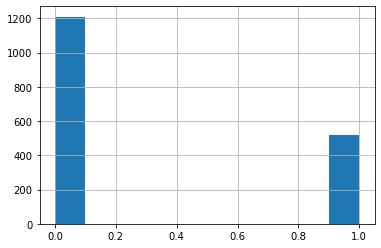

In [33]:
df['class'].hist();

#### 2.2. KNN modeling

In [34]:
# split train set and test set
train = df.sample(frac=0.7,random_state=1).reset_index(drop=True)
train1 = train.drop(['class'], axis = 1) # drop model class 
test = df.drop(train.index).reset_index(drop=True)
test1 = test.drop(['class'], axis = 1) # drop model class 

y_train = np.array(train['class'])
y_true = np.array(test['class'])

In [35]:
# calculate accuracy 
def accuracy(y_true, y_pred):
    correct = np.sum(y_true == y_pred)
    return float(correct)/y_true.shape[0]

In [63]:
# calculate euclidean distance

def e_distance(test_set, test_row, train_set):

    # square distance of each feature 
    f_dist = np.square(train_set.values - test_set.values[test_row])

    # compute total distance 
    dist = np.sqrt(f_dist.sum(axis =1)) 
    
    return(dist)

In [37]:
# create knn model function
def knn_model(test_set, train_set, y_train, k):

    if (k % 2) == 0: 
        print('k should be an odd number')
    else: 
        y_pred = [] # list of prediction

        #loop over each value of test set
        for row in test_set.index:
            
            # calculate euclidean distance
            dist = e_distance(test_set, row, train_set)

            # select top k nearest neighbors
            top_knn_id = dist.argsort()[:k]
            vote = y_train[top_knn_id].mean()    
        
            # define the predicted class
            if vote > 0.5: y_pred.append(1) # assign class 1
            if vote < 0.5: y_pred.append(0) # assign class 0
    
        return(y_pred)

In [38]:
def evaluate_model(y_pred, y_true, k):
    # True Positive (TP)
    TP = np.sum(np.logical_and(y_pred == 1, y_true == 1))
    
    # True Negative (TN)
    TN = np.sum(np.logical_and(y_pred == 0, y_true == 0))
    
    # False Positive (FP)
    FP = np.sum(np.logical_and(y_pred == 1, y_true == 0))
    
    # False Negative
    FN = np.sum(np.logical_and(y_pred == 0, y_true == 1))

    # Accuracy
    acc = (TP+TN)/(TP+TN+FP+FN)

    # False Positive rate
    FP_r = FP/(TN+FP)

    # False Negative rate
    FN_r = FN/(FN+TP)

    # Precision
    p = TP/(TP+FP)

    # Recall
    r = TP/(TP+FN)

    # F-score
    F = (2*p*r)/(p+r)

    return(pd.DataFrame({"k": k, "Accuracy": acc, "False Positive rate": FP_r, "False Negative rate": FN_r, 'False Negative': FN, "Precision": p, "Recall": r, "Recall": r, "F-score": F}, index=[0]))


In [64]:
p_result = knn_model(test1, train1, y_train, 5)

In [65]:
# model accuracy
accuracy(y_true, p_result)

0.9845559845559846

In [66]:
# Confusion matrix
pd.crosstab(y_true, pd.Series(p_result), rownames=['Actual'], colnames=['Predicted'], margins=True)

Predicted,0,1,All
Actual,,,
0,300,4,304
1,4,210,214
All,304,214,518


The model with k = 5 has the accuracy of 98.45%, with 8 variables is misclassified.

In [42]:
# Binary model evaluation metrics
evaluate_model(np.array(p_result), np.array(y_true), 5)

,k,Accuracy,False Positive rate,False Negative rate,False Negative,Precision,Recall,F-score
0,5,0.984556,0.013158,0.018692,4,0.981308,0.981308,0.981308


#### 2.3. Evaluation

In [43]:
neighbors = np.arange(1,21, 2)
df_e = pd.DataFrame()
for k in neighbors:
    pred = knn_model(test1, train1, y_train, k)
    e = evaluate_model(np.array(pred), np.array(test['class']), k)
    df_e = pd.concat([df_e, e], axis = 0).reset_index(drop=True)

In [45]:
df

,buying,maint,doors,persons,lug_boot,safety,class
0,1,1,1,1,1,1,0
1,1,1,1,1,1,2,0
2,1,1,1,1,1,3,0
3,1,1,1,1,2,1,0
4,1,1,1,1,2,2,0
...,...,...,...,...,...,...,...
1723,4,4,4,3,2,2,1
1724,4,4,4,3,2,3,1
1725,4,4,4,3,3,1,0
1726,4,4,4,3,3,2,1


In [46]:
df['class'].value_counts()

0    1210
1     518
Name: class, dtype: int64

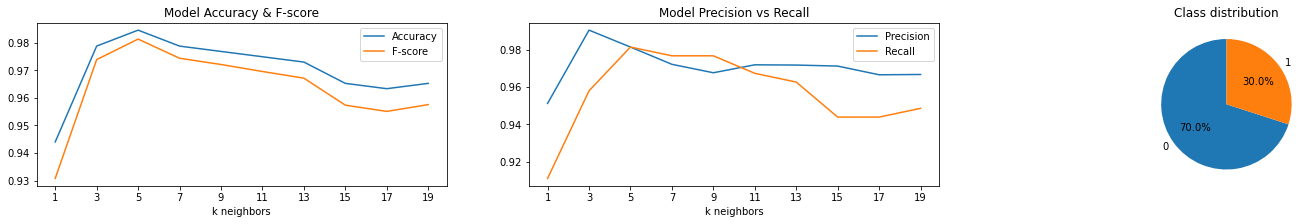

In [ ]:
# plot evaluation metrics
fig, ax = plt.subplots(1, 3, figsize=(25, 5))

# chart 1 acc & F-score
ax[0].plot(df_e['k'],df_e['Accuracy'], label = 'Accuracy')
ax[0].plot(df_e['k'],df_e['F-score'], label = 'F-score')
ax[0].legend()
ax[0].set(title = 'Model Accuracy & F-score', xlabel = 'k neighbors', xticks = neighbors)

# chart 2
ax[1].plot(df_e['k'],df_e['Precision'], label = 'Precision')
ax[1].plot(df_e['k'],df_e['Recall'], label = 'Recall')

# ax1 = ax[1].twinx()  
# ax1.plot(df_e['k'],df_e['False Negative'], label = 'False Negative', color = 'green')

ax[1].legend()
ax[1].set(title = 'Model Precision vs Recall', xlabel = 'k neighbors', xticks = neighbors)

#chart 3
ax[2].pie(df['class'].value_counts(), labels= [0, 1], startangle = 90, autopct='%1.1f%%')
ax[2].set(title = 'Class distribution')

plt.show()

The model achieved a good accuracy rate and F-score when evaluated on a small car dataset. These two metrics show a similar pattern. As the value of k increases (from 7), these metrics values decline.

In terms of both accuracy rate and F-score, the optimal value of k appears to be 5, where the precision and recall values are almost balanced.

As the model exhibits high accuracy, there is only a slight difference between the precision and recall values. When k equals 5 or 7, the recall value is higher than the precision value. This is preferred in cases where the cost of false negatives is high, such as in medical diagnosis. 

### 3. Health Insurance Cross Sell Dataset

Building a model to predict whether a customer would be interested in Vehicle Insurance (0: Customer is not interest in, 1: Customer is interested) as it will help reaching out to those customers and optimise its business model and revenue.

In [77]:
df_1 = pd.read_csv("/Users/hanhnguyen/Downloads/train.csv")
df1 = df_1.sample(frac=0.15,random_state=1).reset_index(drop=True)

In [78]:
df1.dtypes

id                        int64
Gender                   object
Age                       int64
Driving_License           int64
Region_Code             float64
Previously_Insured        int64
Vehicle_Age              object
Vehicle_Damage           object
Annual_Premium          float64
Policy_Sales_Channel    float64
Vintage                   int64
Response                  int64
dtype: object

In [79]:
df1.describe(include='all')

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,57166.000000,57166,57166.000000,57166.000000,57166.000000,57166.000000,57166,57166,57166.000000,57166.000000,57166.00000,57166.000000
unique,NaN,2,NaN,NaN,NaN,NaN,3,2,NaN,NaN,NaN,NaN
top,NaN,Male,NaN,NaN,NaN,NaN,1-2 Year,Yes,NaN,NaN,NaN,NaN
freq,NaN,30815,NaN,NaN,NaN,NaN,29985,28642,NaN,NaN,NaN,NaN
mean,190482.642130,NaN,38.752913,0.997813,26.415667,0.458997,NaN,NaN,30468.525575,112.181139,154.51926,0.120911
std,110076.356667,NaN,15.499536,0.046711,13.211948,0.498320,NaN,NaN,17028.219206,54.103956,83.82814,0.326027
min,2.000000,NaN,20.000000,0.000000,0.000000,0.000000,NaN,NaN,2630.000000,1.000000,10.00000,0.000000
25%,95130.750000,NaN,25.000000,1.000000,15.000000,0.000000,NaN,NaN,24335.000000,29.000000,82.00000,0.000000
50%,190157.000000,NaN,36.000000,1.000000,28.000000,0.000000,NaN,NaN,31613.500000,132.500000,155.00000,0.000000
75%,285959.750000,NaN,49.000000,1.000000,35.000000,1.000000,NaN,NaN,39361.000000,152.000000,227.00000,0.000000


<AxesSubplot:>

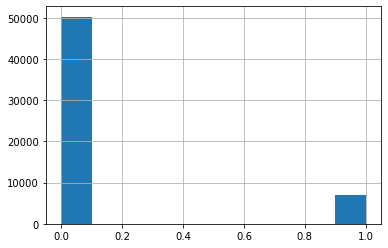

In [80]:
df1['Response'].hist()

In [81]:
(df1.select_dtypes(include=["object"])).apply(lambda x: x.unique())

Gender                             [Female, Male]
Vehicle_Age       [< 1 Year, 1-2 Year, > 2 Years]
Vehicle_Damage                          [No, Yes]
dtype: object

In [82]:
def encoding_scaling_data(df):

    # drop id
    df = df.drop(['id'], axis = 1)
    
    # encoding
    df['Gender'] = df['Gender'].apply(lambda x: "1" if x == "Male" else "0").astype(int)
    df['Vehicle_Age'] = df['Vehicle_Age'].apply(lambda x: "-1" if x == "< 1 Year" else "0" if x == "1-2 Year" else "1").astype(int)
    df['Vehicle_Damage'] = df['Vehicle_Damage'].apply(lambda x: "1" if x == "Yes" else "0").astype(int)
    
    # normalization
    for i in ['Age', 'Region_Code', 'Annual_Premium', 'Policy_Sales_Channel', 'Vintage']:
        min = df[i].min()
        max = df[i].max()
        df[i] = df[i].apply(lambda x: (x - min)/(max - min))
    
    return(df)   


In [100]:
df1_new = encoding_scaling_data(df1)
df1_new


,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,0,0.061538,1,0.576923,1,-1,0,0.058139,0.932099,0.674740,0
1,0,0.246154,1,0.538462,1,0,0,0.049489,0.746914,0.961938,0
2,1,0.553846,1,0.403846,0,0,1,0.079891,0.154321,0.965398,1
3,1,0.015385,1,0.576923,1,-1,1,0.046960,0.932099,0.408304,0
4,0,0.676923,1,0.961538,0,0,1,0.074721,0.154321,0.837370,1
...,...,...,...,...,...,...,...,...,...,...,...
57161,1,0.646154,1,0.961538,0,0,1,0.097166,0.043210,0.719723,0
57162,0,0.061538,1,0.134615,0,-1,1,0.071206,0.932099,0.124567,0
57163,1,0.169231,1,0.057692,0,0,1,0.060192,0.759259,0.647059,0
57164,1,0.646154,1,0.538462,1,0,0,0.051600,0.950617,0.688581,0


In [84]:
# split train set and test set
train_1 = df1_new.sample(frac=0.7,random_state=1).reset_index(drop=True)
train_2 = train_1.drop(['Response'], axis = 1) # drop model class 
test_1 = df1_new.drop(train_1.index).reset_index(drop=True)
test_2 = test_1.drop(['Response'], axis = 1) # drop model class 

y_train2 = np.array(train_1['Response'])
y_true2 = np.array(test_1['Response'])

In [85]:
p_result2 = knn_model(test_2, train_2, y_train2, 5)

In [86]:
evaluate_model(np.array(p_result2), np.array(y_true2), 5)

,k,Accuracy,False Positive rate,False Negative rate,False Negative,Precision,Recall,F-score
0,5,0.885773,0.031074,0.713739,1491,0.560976,0.286261,0.379081


In [89]:
neighbors = np.arange(1,21, 2)
df_e2 = pd.DataFrame()
for k in neighbors:
    pred = knn_model(test_2, train_2, y_train2, k)
    e_2 = evaluate_model(np.array(pred), np.array(test_1['Response']), k)
    df_e2 = pd.concat([df_e2, e_2], axis = 0).reset_index(drop=True)

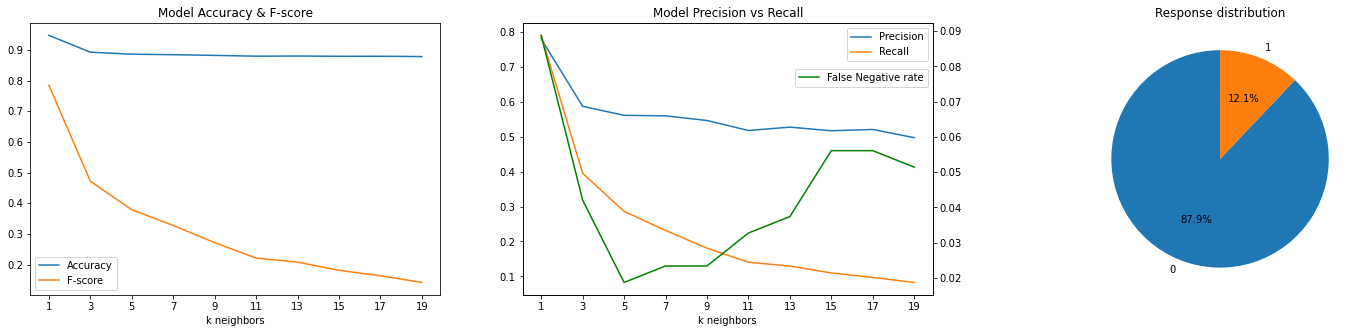

In [94]:
# plot evaluation metrics
fig, ax = plt.subplots(1, 3, figsize=(25, 5))

# chart 1 acc & F-score
ax[0].plot(df_e2['k'],df_e2['Accuracy'], label = 'Accuracy')
ax[0].plot(df_e2['k'],df_e2['F-score'], label = 'F-score')
ax[0].legend()
ax[0].set(title = 'Model Accuracy & F-score', xlabel = 'k neighbors', xticks = neighbors)

# chart 2
ax[1].plot(df_e2['k'],df_e2['Precision'], label = 'Precision')
ax[1].plot(df_e2['k'],df_e2['Recall'], label = 'Recall')
ax1 = ax[1].twinx()  
ax1.plot(df_e2['k'],df_e['False Negative rate'], label = 'False Negative rate', color = 'green')
ax[1].legend()
ax1.legend(bbox_to_anchor=(1, 0.85))
ax[1].set(title = 'Model Precision vs Recall', xlabel = 'k neighbors', xticks = neighbors)

# chart 3
ax[2].set(title = 'Response distribution')
ax[2].pie(df1['Response'].value_counts(), labels= [0, 1], startangle = 90, autopct='%1.1f%%')
plt.show()

In [101]:
# Confusion matrix
pd.crosstab(y_true2, pd.Series(knn_model(test_2, train_2, y_train2, 7)), rownames=['Actual'], colnames=['Predicted'], margins=True)

Predicted,0,1,All
Actual,,,
0,14680,381,15061
1,1605,484,2089
All,16285,865,17150


In [99]:
len(y_true2)

17150

In this dataset, the majority class is class 0, with over 50k instances in total of 57166 rows. This class imbalance can result in bias during prediction, particularly when k neighbors is small. 

When the k value increases, there is a significant difference between precision and recall values, indicating the need for careful consideration of trade-offs. In the case of this dataset, recall value is more important as we don't want to miss potential customers. In the second chart, it can be seen that the optimal selection of k value is between 5 to 9 for low false negative rate.

### 4. Summary